# Notebook 07 — Baseline Models
SeasonalNaive (lag=365) and EMA (span=30) baselines on the last CV fold (val=2022).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_config, set_seed, ensure_dirs
from src.data_loader import load_sales
from src.models.baseline import SeasonalNaiveModel, EMAModel
from src.metrics import evaluate, compare_models

cfg = load_config('../config.yaml')
cfg['paths']['dataset']     = '../dataset'
cfg['paths']['outputs']     = '../outputs'
cfg['paths']['figures']     = '../outputs/figures'
cfg['paths']['models']      = '../outputs/models'
cfg['paths']['cv_results']  = '../outputs/cv_results'
cfg['paths']['submissions'] = '../outputs/submissions'
cfg['paths']['report_figures'] = '../report/figures'

set_seed(cfg['seed'])
ensure_dirs(cfg)
print('Config loaded.')

Config loaded.


In [2]:
# Load sales data
sales = load_sales(cfg)
print(f'Sales shape: {sales.shape}')
print(f'Date range: {sales["Date"].min().date()} to {sales["Date"].max().date()}')

# Train/val split: train <= 2021-12-31, val = 2022
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END   = '2022-12-31'

train = sales[sales['Date'] <= TRAIN_END].copy()
val   = sales[(sales['Date'] >= VAL_START) & (sales['Date'] <= VAL_END)].copy()

print(f'Train: {len(train)} rows  ({train["Date"].min().date()} to {train["Date"].max().date()})')
print(f'Val  : {len(val)} rows  ({val["Date"].min().date()} to {val["Date"].max().date()})')

Sales shape: (3833, 3)
Date range: 2012-07-04 to 2022-12-31
Train: 3468 rows  (2012-07-04 to 2021-12-31)
Val  : 365 rows  (2022-01-01 to 2022-12-31)


In [3]:
# SeasonalNaive (lag=365)
sn_model = SeasonalNaiveModel(season=365)
sn_model.fit(train['Date'].values, train['Revenue'].values)
sn_preds = sn_model.predict_series(val['Date'].values)

metrics_sn = evaluate(val['Revenue'].values, sn_preds, label='SeasonalNaive(lag=365)')

# EMA (span=30)
ema_model = EMAModel(span=30)
ema_model.fit(train['Date'].values, train['Revenue'].values)
ema_preds = ema_model.predict_series(val['Date'].values)

metrics_ema = evaluate(val['Revenue'].values, ema_preds, label='EMA(span=30)')

[SeasonalNaive(lag=365)]  MAE=837,704  RMSE=1,161,819  R2=0.5182  Composite=0.5742
[EMA(span=30)]  MAE=1,514,086  RMSE=2,110,518  R2=-0.5899  Composite=1.1842


In [4]:
# Comparison table
results = {
    'SeasonalNaive(lag=365)': metrics_sn,
    'EMA(span=30)': metrics_ema,
}
comparison = compare_models(results)
print('\n=== Baseline Model Comparison (Val 2022) ===')
display(comparison)


=== Baseline Model Comparison (Val 2022) ===


,mae,rmse,r2,composite
SeasonalNaive(lag=365),"837,704","1,161,819",0.5182,0.5742
EMA(span=30),"1,514,086","2,110,518",-0.5899,1.1842


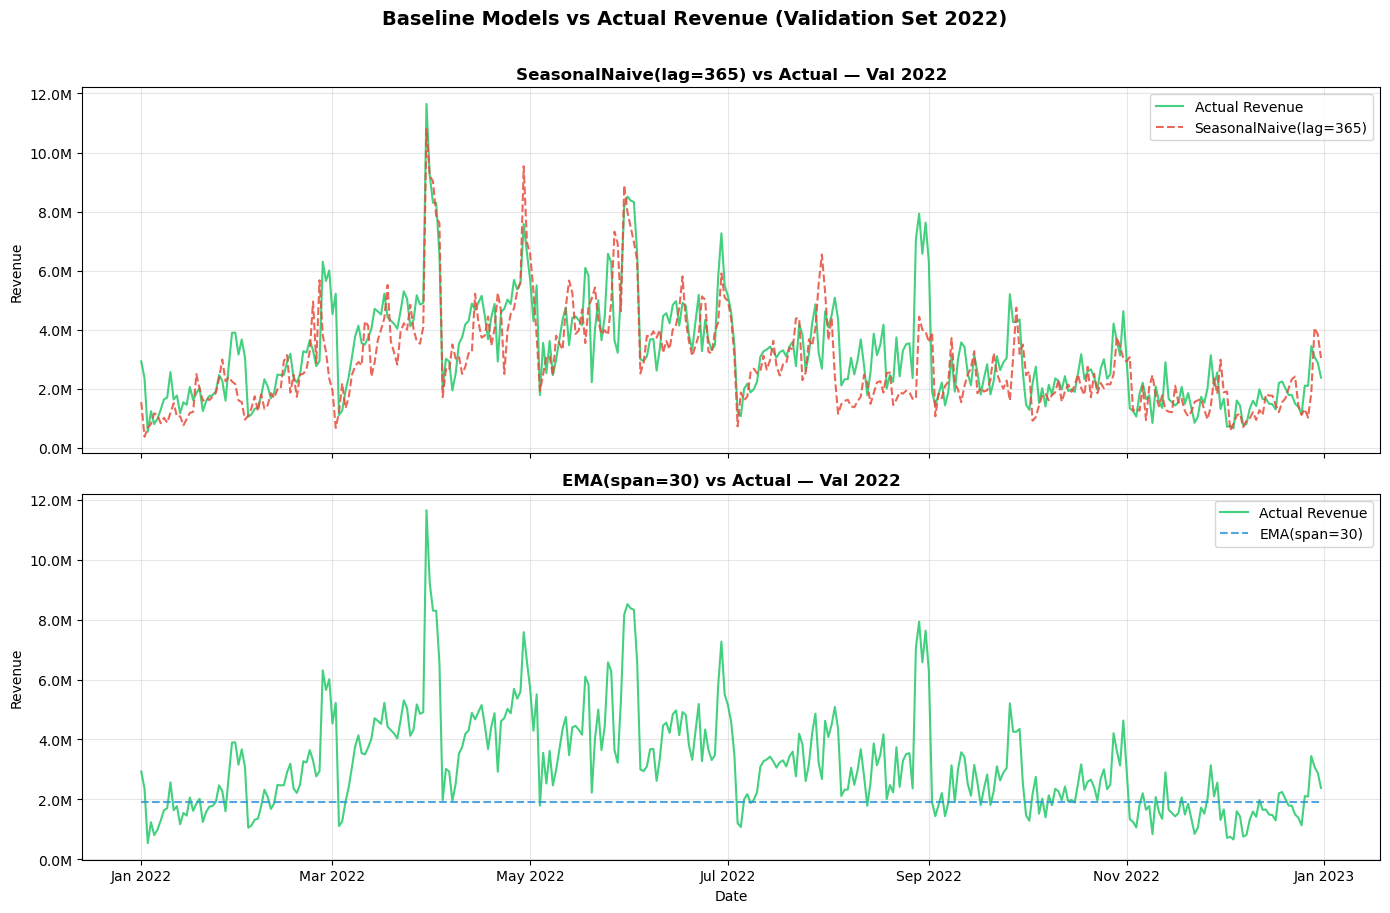

Saved: ../outputs/figures/07_baseline_predictions.png


In [5]:
# Plot: Actual vs Baseline Predictions on val set
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

val_dates = val['Date'].values
actual    = val['Revenue'].values

# Panel 1: SeasonalNaive
axes[0].plot(val_dates, actual, color='#2ecc71', lw=1.5, label='Actual Revenue', alpha=0.9)
axes[0].plot(val_dates, sn_preds, color='#e74c3c', lw=1.5, ls='--', label='SeasonalNaive(lag=365)', alpha=0.85)
axes[0].set_title('SeasonalNaive(lag=365) vs Actual — Val 2022', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Panel 2: EMA
axes[1].plot(val_dates, actual, color='#2ecc71', lw=1.5, label='Actual Revenue', alpha=0.9)
axes[1].plot(val_dates, ema_preds, color='#3498db', lw=1.5, ls='--', label='EMA(span=30)', alpha=0.85)
axes[1].set_title('EMA(span=30) vs Actual — Val 2022', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenue')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Baseline Models vs Actual Revenue (Validation Set 2022)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

fig_path = cfg['paths']['figures'] + '/07_baseline_predictions.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [6]:
# Save predictions
import pathlib
os.makedirs(cfg['paths']['cv_results'], exist_ok=True)

baseline_preds = pd.DataFrame({
    'Date': val['Date'].values,
    'Actual': actual,
    'SeasonalNaive_lag365': sn_preds,
    'EMA_span30': ema_preds,
})

save_path = cfg['paths']['cv_results'] + '/baseline_preds.csv'
baseline_preds.to_csv(save_path, index=False)
print(f'Saved baseline predictions: {save_path}')
print(f'Shape: {baseline_preds.shape}')

print('\n=== Summary ===')
print(f'SeasonalNaive MAE : {metrics_sn["mae"]:>12,.0f}')
print(f'SeasonalNaive RMSE: {metrics_sn["rmse"]:>12,.0f}')
print(f'SeasonalNaive R2  : {metrics_sn["r2"]:>12.4f}')
print(f'EMA(30) MAE       : {metrics_ema["mae"]:>12,.0f}')
print(f'EMA(30) RMSE      : {metrics_ema["rmse"]:>12,.0f}')
print(f'EMA(30) R2        : {metrics_ema["r2"]:>12.4f}')
print('\nBaseline notebook complete.')

Saved baseline predictions: ../outputs/cv_results/baseline_preds.csv
Shape: (365, 4)

=== Summary ===
SeasonalNaive MAE :      837,704
SeasonalNaive RMSE:    1,161,819
SeasonalNaive R2  :       0.5182
EMA(30) MAE       :    1,514,086
EMA(30) RMSE      :    2,110,518
EMA(30) R2        :      -0.5899

Baseline notebook complete.
